# Zero-Gain Limit Comparison

This notebook compares different zero-gain limits for a pipeline consisting of four consecutive applications of `move_plateau`.

The analyzed limits are:

- $1|V|$
- $2|V|$
- $4|V|$
- $8|V|$

It produces:

1. a comparison of relative solution quality
2. a comparison of run time

The analysis is grouped by graph type, size class, and density regime.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("default")

## Configuration

In [2]:
ZERO_GAIN_FACTORS = [1, 2, 4, 8]

PLATEAU_STEPS = 4
PLATEAU_PIPELINE = ",".join(["move_plateau"] * PLATEAU_STEPS)

GRAPH_ORDER = ["powerlaw", "er"]

DATASET_ORDER = [
    "small sparse",
    "small dense",
    "large sparse",
    "large dense",
]

GRAPH_TYPE_LABELS = {
    "powerlaw": "Powerlaw",
    "er": "Erdős–Rényi",
}

RESULTS_DIR = Path("../../results/experiment2/zero_gain_limit")
RAW_RESULTS_FILE = RESULTS_DIR / "raw_results.csv"

PLOTS_DIR = RESULTS_DIR.parents[1] / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

## Load data

In [3]:
raw = pd.read_csv(RAW_RESULTS_FILE)

raw["dataset_group"] = raw["size_class"].astype(str) + " " + raw["regime"].astype(str)

raw["graph_type"] = pd.Categorical(
    raw["graph_type"],
    categories=GRAPH_ORDER,
    ordered=True,
)

raw["dataset_group"] = pd.Categorical(
    raw["dataset_group"],
    categories=DATASET_ORDER,
    ordered=True,
)

raw = raw[(raw["pipeline"] == PLATEAU_PIPELINE) & raw["zero_gain_factor"].isin(ZERO_GAIN_FACTORS)].copy()

raw["zero_gain_factor"] = pd.Categorical(
    raw["zero_gain_factor"].astype(int),
    categories=ZERO_GAIN_FACTORS,
    ordered=True,
)

# Solution quality

For every instance and zero_gain_factor, only the run with the highest final solution quality is retained.

The best result across all compared factors is used as the reference. Relative solution quality is defined as

$
\frac{\text{best result across all factors}}
     {\text{result of the respective factor}}.
$

A value of $1.0$ means that the factor matches the best result found on the same instance. Values greater than $1.0$ indicate the remaining quality gap.

In [4]:
best_run_keys = [
    "graph_type",
    "dataset_group",
    "dataset",
    "instance",
    "zero_gain_factor",
]

best_runs = (
    raw
    .sort_values(["final_density", "ls_runtime", "run"], ascending=[False, True, True])
    .groupby(best_run_keys, observed=True, as_index=False)
    .head(1)
    .reset_index(drop=True)
)

In [5]:
instance_keys = [
    "graph_type",
    "dataset_group",
    "dataset",
    "instance",
]

density_table = best_runs.pivot_table(
    index=instance_keys,
    columns="zero_gain_factor",
    values="final_density",
    observed=True,
)[ZERO_GAIN_FACTORS]

best_per_instance = density_table.max(axis=1)

relative_to_best = density_table.rdiv(best_per_instance, axis=0)

quality_summary = (
    relative_to_best
    .groupby(level=["graph_type", "dataset_group"])
    .mean()
    .stack()
    .rename("mean_relative_to_best")
    .reset_index()
)

quality_summary

,graph_type,dataset_group,zero_gain_factor,mean_relative_to_best
0,powerlaw,small sparse,1,1.000809
1,powerlaw,small sparse,2,1.000505
2,powerlaw,small sparse,4,1.000457
3,powerlaw,small sparse,8,1.000370
4,powerlaw,small dense,1,1.002967
5,powerlaw,small dense,2,1.001471
6,powerlaw,small dense,4,1.001398
7,powerlaw,small dense,8,1.001254
8,powerlaw,large sparse,1,1.001350
9,powerlaw,large sparse,2,1.000619


## Relative solution quality

The figures show the mean relative solution quality for each zero-gain limit.
A value of 1 indicates the best solution found among all compared limits.

In [6]:
def plot_relative_quality(summary: pd.DataFrame, graph_type: str, output_path: Path | None = None) -> None:
    graph_data = summary[summary["graph_type"] == graph_type].sort_values(["dataset_group", "zero_gain_factor"])

    fig, ax = plt.subplots(figsize=(8, 5))

    for dataset_group, group_data in graph_data.groupby("dataset_group", observed=True):
        ax.plot(
            group_data["zero_gain_factor"].astype(int),
            group_data["mean_relative_to_best"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=dataset_group,
        )

    ax.axhline(
        1.0,
        linestyle="--",
        color="gray",
        linewidth=1,
        label="Best solution found",
    )

    ax.set_xlabel("Zero-gain limit")
    ax.set_ylabel("Mean relative solution quality")
    ax.set_title(f"Relative solution quality ({GRAPH_TYPE_LABELS[graph_type]})")
    ax.set_xticks(ZERO_GAIN_FACTORS)
    ax.set_xticklabels([f"{factor}|V|" for factor in ZERO_GAIN_FACTORS])

    ax.set_ylim(
        graph_data["mean_relative_to_best"].min() - 0.0005,
        graph_data["mean_relative_to_best"].max() + 0.0005,
    )

    ax.legend(title="Dataset")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()

    if output_path is not None:
        fig.savefig(
            output_path,
            bbox_inches="tight",
            facecolor="white",
        )

    plt.show()
    plt.close(fig)

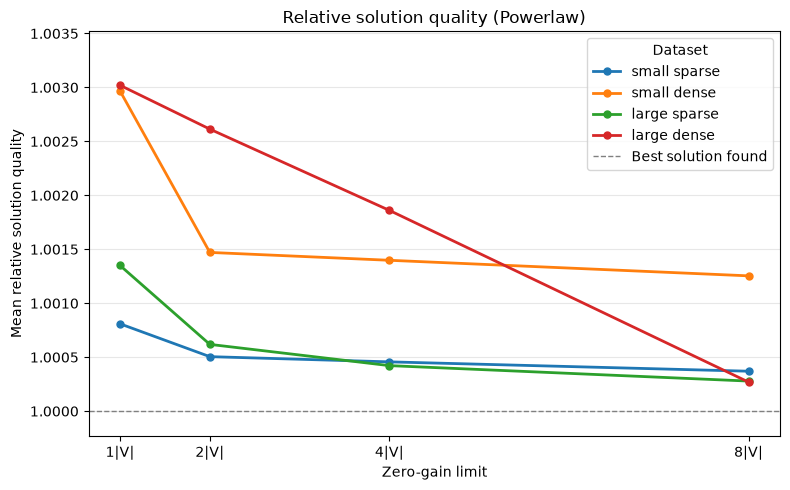

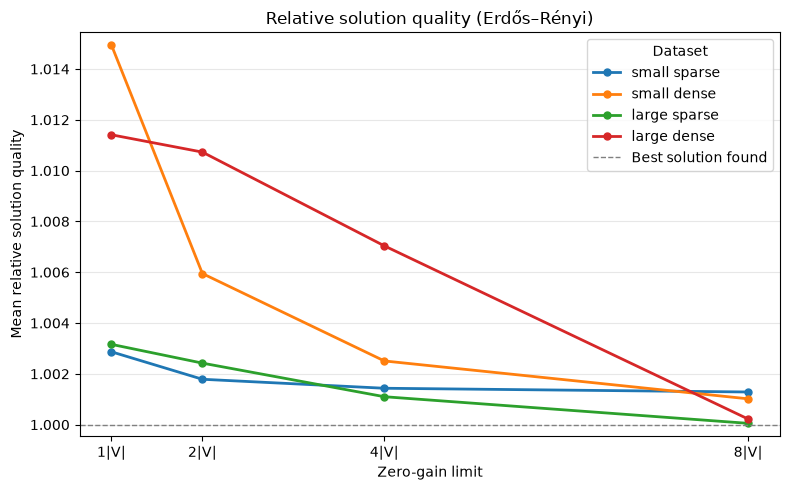

In [7]:
plot_relative_quality(
    quality_summary,
    "powerlaw",
    PLOTS_DIR / "powerlaw_zero_gain_quality.png",
)

plot_relative_quality(
    quality_summary,
    "er",
    PLOTS_DIR / "er_zero_gain_quality.png",
)

## Run time

The reported run time is the total local-search run time of all runs for one instance and zero_gain_factor, averaged over all instances in the corresponding dataset group.

In [8]:
runtime_per_instance = (
    raw
    .groupby(best_run_keys, observed=True, as_index=False)
    .agg(
        total_runtime=("ls_runtime", "sum"),
        moves_per_run=("num_moves", "mean"),
        passes_per_run=("num_passes", "mean"),
    )
)

runtime_summary = (
    runtime_per_instance
    .groupby(["graph_type", "dataset_group", "zero_gain_factor",], observed=True, as_index=False)
    .agg(
        mean_runtime=("total_runtime", "mean"),
        mean_moves_per_run=("moves_per_run", "mean"),
        mean_passes_per_run=("passes_per_run", "mean"),
    )
)

runtime_summary

,graph_type,dataset_group,zero_gain_factor,mean_runtime,mean_moves_per_run,mean_passes_per_run
0,powerlaw,small sparse,1,28.871915,649.31635,73.24270
1,powerlaw,small sparse,2,61.011081,1246.68450,165.33565
2,powerlaw,small sparse,4,127.627222,2441.42100,356.15580
3,powerlaw,small sparse,8,263.124954,4830.04360,742.80820
4,powerlaw,small dense,1,50.231958,655.83720,54.55060
5,powerlaw,small dense,2,110.396184,1254.56080,125.28700
6,powerlaw,small dense,4,238.732760,2450.73415,277.41540
7,powerlaw,small dense,8,498.208946,4842.45995,586.35045
8,powerlaw,large sparse,1,231.014780,4353.62975,59.53105
9,powerlaw,large sparse,2,478.513178,8385.21050,131.51165


## Run time development

The figures show the mean total run time of the ten randomized runs for each zero-gain limit.

In [9]:
def plot_total_runtime(summary: pd.DataFrame, graph_type: str, output_path: Path | None = None) -> None:
    graph_data = summary[summary["graph_type"] == graph_type].sort_values(["dataset_group", "zero_gain_factor"])

    fig, ax = plt.subplots(figsize=(8, 5))

    for dataset_group, group_data in graph_data.groupby("dataset_group", observed=True):
        ax.plot(
            group_data["zero_gain_factor"].astype(int),
            group_data["mean_runtime"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=dataset_group,
        )

    ax.set_xlabel("Zero-gain limit")
    ax.set_ylabel("Mean total run time of ten runs (s)")
    ax.set_title(f"Total run time ({GRAPH_TYPE_LABELS[graph_type]})")
    ax.set_xticks(ZERO_GAIN_FACTORS)
    ax.set_xticklabels([f"{factor}|V|" for factor in ZERO_GAIN_FACTORS])

    ax.legend(title="Dataset")
    ax.grid(axis="y", alpha=0.3)

    fig.tight_layout()

    if output_path is not None:
        fig.savefig(
            output_path,
            bbox_inches="tight",
            facecolor="white",
        )

    plt.show()
    plt.close(fig)

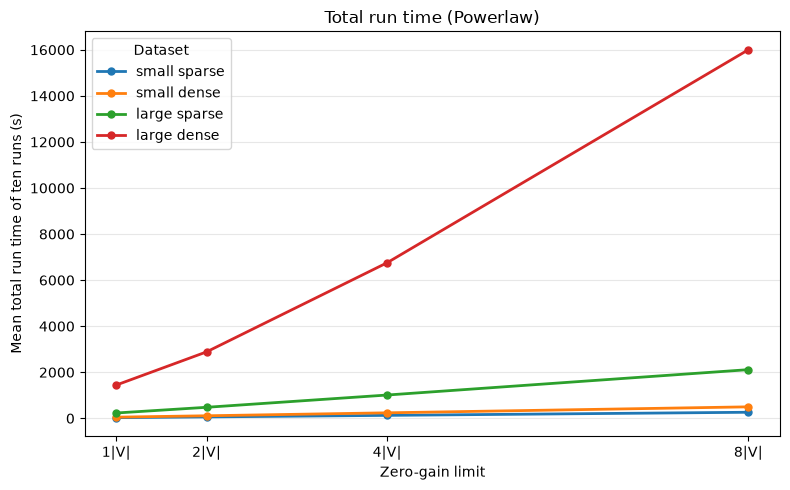

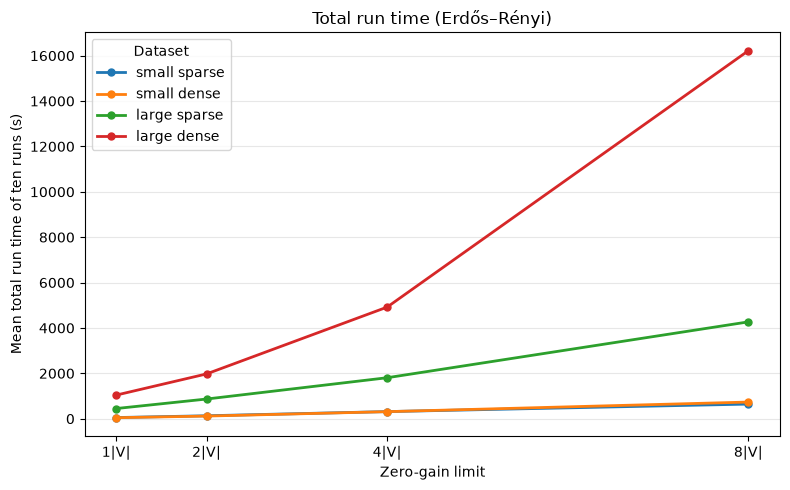

In [11]:
plot_total_runtime(
    runtime_summary,
    "powerlaw",
    PLOTS_DIR / "powerlaw_zero_gain_runtime.png",
)

plot_total_runtime(
    runtime_summary,
    "er",
    PLOTS_DIR / "er_zero_gain_runtime.png",
)